In [27]:
#!/usr/bin/env python
# coding: utf-8
import argparse
from typing import cast
import numpy as np
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader, random_split
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import torch.nn as nn
from tqdm.notebook import tqdm
import zipfile
import os
import numpy as np
import math
from torchvision.transforms import v2
from transformers import AutoTokenizer, GPT2LMHeadModel, GPT2Config
import transformers
import random
import mingpt.data as data
import shlex
import argparse
import mingpt.gen as gen
import vqvae

In [28]:
device="cuda"

In [29]:
# Create the parser
import argparse
parser = argparse.ArgumentParser()

# Add arguments

parser.add_argument('--dataset_type', type=str, help='type of dataset, can only be "mnist", "fashion", "spirit" or "face"')
# work directory of the model
# the plot and model will be saved to this directory
# I recommend you to use different work directory for different hyper parameters
parser.add_argument('--work_dir', type=str)
parser.add_argument('--data_dir', type=str)
# logging interval, you can increase this value if there are too many logs
parser.add_argument('--log_iter', type=int, default=300)
# checkpoint interval
parser.add_argument('--save_iter', type=int, default=1000)
# evaluation interval
parser.add_argument('--eval_iter', type=int, default=300)
# embedding size of GPT2 model
parser.add_argument('--n_embed', type=int, default=256)
# number of attention head
parser.add_argument('--n_head', type=int, default=8)
# number of layer
parser.add_argument('--n_layer', type=int)

# hyper parameter
parser.add_argument('--batch_size', type=int)
parser.add_argument('--learning_rate', type=float)
parser.add_argument('--n_epoch', type=int)
parser.add_argument('--pdropout', type=float)

# I prefer 1000 for learning rate, it should be around 1% of the total training steps
parser.add_argument('--n_warmup', type=int)
# set to 2 for mnist and fashion dataset, if you want a quick experiment
# this will downscale the image to a smaller size
parser.add_argument('--downscale', type=int)

# parameter used only in evaluation
# if you want to perform evaluation with a model, then provide the fullpath to a model.pt file
parser.add_argument('--checkpoint', type=str)
# row = 5 will generate 5*5 images
parser.add_argument('--row', type=int, default=5)
# higher temperature will increase diversity of output, you can tune this parameter by yourself
parser.add_argument('--temperature', type=float, default=1.0)
# try 2 to 5, will slow down generation
parser.add_argument('--num_beams', type=int, default=2)

# vqvae parameter
parser.add_argument('--vqvae_checkpoint', type=str)

# important!!!
# you must set seed to 0 during training for reproducibility 
# for evaluation you can ignore this parameter, then the script will pick a seed for you
parser.add_argument('--seed', type=int, default=random.randrange(100000))

# whether we do unconditional generation
parser.add_argument('--unconditional', action='store_true')
example = """
--dataset_type vqvae-face \
       --work_dir work/mingpt \
       --log_iter 300 \
       --save_iter 1000 \
       --eval_iter 3000 \
       --n_embed 256 \
       --n_head 8 \
       --n_layer 4 \
       --pdropout 0.0 \
       --batch_size 16 \
       --learning_rate 2e-4 \
       --n_epoch 64 \
       --n_warmup 3000 \
       --downscale 1 \
       --row 5 \
       --num_beams 2 \
       --temperature 1 \
       --data_dir=data \
       --vqvae_checkpoint=work/vqvae/results/face-vqvae.pt \
       --unconditional
"""
def in_ipython():
    try:
        return __IPYTHON__
    except NameError:
        return False
    
if in_ipython():
    args = parser.parse_args(shlex.split(example))
else:
    args = parser.parse_args()
print(args)
for dir in ['plot', 'runs', 'model']:
    pp = os.path.join(args.work_dir, dir)
    if not os.path.exists(pp):
        os.mkdir(pp)

if args.checkpoint is None:
    is_training = True
else:
    is_training = False

random.seed(args.seed)
import numpy as np
np.random.seed(args.seed)
import torch
torch.manual_seed(args.seed)

total_data, custom_dataset_info = data.get_data(args.dataset_type, args.data_dir, downscale=args.downscale)
flatten_database = custom_dataset_info.flatten_images
if args.unconditional:
    text_codebook_size = 0
else:
    text_codebook_size = custom_dataset_info.label_num

from vqvae.model import VQVAE, CodeLayer
import vqvae
vqvae_model = None
if custom_dataset_info.vqvae:
    assert args.vqvae_checkpoint != None
    vqvae_model = vqvae.utils.load_module(args.vqvae_checkpoint).to(device)
    vqvae_model.eval()
    # test_data = torch.IntTensor(np.load("vqvae/imagenet_image_token.npy")[0:64]).to(device)
    # vqvae_model.load_state_dict(torch.load(args.vqvae_checkpoint)["model"])
    # vqvae_model.eval()
    # outputs = vqvae.utils.decode_latent(vqvae_model, test_data, (64,64)) # (b, c, w, h)
    # outputs = ((outputs + 1) / 2) 
    # images = outputs.permute((0, 2,3,1))
    # images = images.detach().cpu().numpy()
    # plt.imshow(images[1])
    # plt.savefig("test.png")
    image_codebook_size = 0
    token_length = 0
    for i in vqvae_model.codebooks:
        ci = cast(CodeLayer, i)
        image_codebook_size += ci.n_embed
    token_length = len(vqvae.utils.get_latent_offset(vqvae_model, custom_dataset_info.shape[:-1]))
else:
    image_codebook_size = 256
    token_length = math.prod(custom_dataset_info.shape)

total_vocab_size = image_codebook_size + 2 + text_codebook_size


"""
[0, image_codebook_size] image code book vocab
[image_codebook_size, image_codebook_size + text_codebook_size) text code book vocab
[image_codebook_size + text_codebook_size, image_codebook_size + text_codebook_size + 2) special token
"""

config = gen.ExperimentConfig(
    work_dir = args.work_dir,
    checkpoint = args.checkpoint,
    shape = custom_dataset_info.shape,
    image_token_length = token_length,
    # one class token, two special tokens and image tokens
    total_length = token_length + 2 + (not args.unconditional),
    special_token_num = 2,
    bos_id = image_codebook_size + text_codebook_size,
    eos_id = image_codebook_size + text_codebook_size + 1,
    row=args.row,
    temperature=args.temperature,
    num_beams=args.num_beams,

    dataset_type = args.dataset_type,
    downscale=args.downscale,

    # tunable hyperparameter for training
    batch_size = args.batch_size,
    learning_rate = args.learning_rate,
    n_epoch = args.n_epoch,
    n_warmup =  args.n_warmup,
    pdropout = args.pdropout,

    log_iter = args.log_iter,
    save_iter = args.save_iter,
    eval_iter = args.eval_iter,

    # hyperparameter for model (default is 3M)
    n_embed = args.n_embed,
    n_head = args.n_head,
    n_layer = args.n_layer,
    use_vqvae = custom_dataset_info.vqvae, # whether use vqvae to compress the image first
    vqvae_checkpoint = args.vqvae_checkpoint,
    total_vocab_size = total_vocab_size,
    image_codebook_size = image_codebook_size,
    text_codebook_size=text_codebook_size,
    unconditional=args.unconditional
)

Namespace(dataset_type='vqvae-face', work_dir='work/mingpt', data_dir='data', log_iter=300, save_iter=1000, eval_iter=3000, n_embed=256, n_head=8, n_layer=4, batch_size=16, learning_rate=0.0002, n_epoch=64, pdropout=0.0, n_warmup=3000, downscale=1, checkpoint=None, row=5, temperature=1.0, num_beams=2, vqvae_checkpoint='work/vqvae/results/face-vqvae.pt', seed=14722, unconditional=True)


In [30]:
sliding_window_size = 16
config.total_length = sliding_window_size * sliding_window_size + 2 + (not args.unconditional)
config.image_token_length = None

In [5]:
config

ExperimentConfig(work_dir='work/mingpt', checkpoint=None, shape=(64, 64, 3), image_token_length=None, total_length=51, special_token_num=2, bos_id=128, eos_id=129, row=5, temperature=1.0, num_beams=2, dataset_type='vqvae-face', downscale=1, batch_size=16, learning_rate=0.0002, n_epoch=64, pdropout=0.0, n_warmup=3000, log_iter=300, save_iter=1000, eval_iter=3000, n_embed=256, n_head=8, n_layer=4, use_vqvae=True, vqvae_checkpoint='work/vqvae/results/face-vqvae.pt', total_vocab_size=130, image_codebook_size=128, text_codebook_size=0, unconditional=True)

In [6]:
device="cuda"
pdrop = config.pdropout
model_config = GPT2Config(
    vocab_size=config.total_vocab_size,
    n_positions=config.total_length,
    bos_token_id=config.bos_id,
    eos_token_id=config.eos_id,
    n_embd = config.n_embed,
    n_layer = config.n_layer,
    n_head = config.n_head,
    resid_pdrop=pdrop,
    embd_pdrop=pdrop,      
    attn_pdrop=pdrop
)
model = GPT2LMHeadModel(model_config)
model = model.to(device)
model_config

GPT2Config {
  "activation_function": "gelu_new",
  "attn_pdrop": 0.0,
  "bos_token_id": 128,
  "embd_pdrop": 0.0,
  "eos_token_id": 129,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_embd": 256,
  "n_head": 8,
  "n_inner": null,
  "n_layer": 4,
  "n_positions": 51,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.0,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "transformers_version": "4.38.2",
  "use_cache": true,
  "vocab_size": 130
}

In [7]:
training_data, eval_data = random_split(total_data, [0.9, 0.1])
optimizer = torch.optim.AdamW(model.parameters(), betas=(0.9,0.95), lr=config.learning_rate, weight_decay=0.1)
num_epochs = config.n_epoch
bs = config.batch_size
train_dl = DataLoader(training_data, batch_size=bs, shuffle=True, drop_last=True)
eval_dl =  DataLoader(eval_data, batch_size=bs, shuffle=False, drop_last=True)
device = "cuda"
num_training_steps = num_epochs * len(train_dl)
lr_scheduler = transformers.get_constant_schedule_with_warmup(
        optimizer,
        num_warmup_steps=config.n_warmup
    )

In [8]:
from torch.utils.tensorboard.writer import SummaryWriter
writer = SummaryWriter(log_dir=os.path.join(config.work_dir, 'runs'))
bs = config.batch_size
num_training_steps = len(train_dl) * config.n_epoch
model.to(device)
print(config)
# you can see the config in tensorboard's text section
writer.add_text('experiment config', str(config))
writer.add_text('model_size', str(sum([i.numel() for i in model.parameters()]))) 
log_iter = config.log_iter
eval_iter = config.eval_iter
save_iter = config.save_iter
offset_f = lambda x : x + config.image_codebook_size

2024-04-14 18:17:13.585265: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-04-14 18:17:13.611375: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-14 18:17:14.374634: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


ExperimentConfig(work_dir='work/mingpt', checkpoint=None, shape=(64, 64, 3), image_token_length=None, total_length=51, special_token_num=2, bos_id=128, eos_id=129, row=5, temperature=1.0, num_beams=2, dataset_type='vqvae-face', downscale=1, batch_size=16, learning_rate=0.0002, n_epoch=64, pdropout=0.0, n_warmup=3000, log_iter=300, save_iter=1000, eval_iter=3000, n_embed=256, n_head=8, n_layer=4, use_vqvae=True, vqvae_checkpoint='work/vqvae/results/face-vqvae.pt', total_vocab_size=130, image_codebook_size=128, text_codebook_size=0, unconditional=True)


In [9]:
def plot_sample(x):
    x = x.cpu().detach().numpy()
    x = x[0]
    plt.imshow(x, cmap="gray")
    plt.show()

In [10]:
next(iter(train_dl))[0].shape

torch.Size([16, 256])

In [11]:
sliding_window_size

7

In [13]:
coordination_embedding = torch.nn.Embedding(16 * 16, config.n_embed)

In [24]:
def get_all_coordination(ch, cw):
    pa = sliding_window_size // 2
    result = []
    for i in range(ch - pa, ch + pa + 1):
        for j in range(cw - pa, cw + pa + 1):
            s = i * 16 + j
            result.append(s)
    return torch.tensor(result).to(device)

256 torch.Size([4, 256])


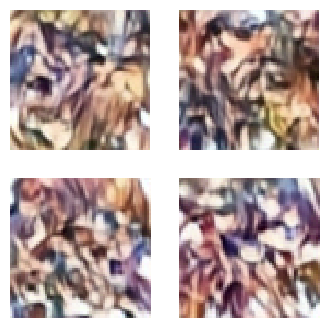

In [26]:
def top_k_logits(logits, k):
    v, _ = torch.topk(logits, k)
    out = logits.clone()
    out[out < v[:, :, [-1]]] = -float('Inf')
    return out
def generate_images(nrow, ncol, name):
    global buffer
    bs = nrow * ncol
    if config.use_vqvae:
        h, w = (16, 16)
        assert h * w == next(iter(train_dl))[0].shape[-1]
    else:
        h, w = custom_dataset_info.shape[:-1]
    buffer = torch.full((bs, h, w), -114515 , dtype = torch.int32).to(device)
    start_token = torch.full((bs,1), config.bos_id).to(device)
    eos_token = torch.full((bs,1), config.eos_id).to(device)
    temperature = 1.0
    top_k = 100
    def clip(x, vmin, vmax):
        return min(max(vmin, x), vmax)
    if not config.unconditional:
        labels = torch.arange(0, bs).unsqueeze(-1) % config.text_codebook_size
        label_tokens =  labels + config.image_codebook_size
        assert len(label_tokens.shape) == 2
        label_tokens = label_tokens.to(device)
    for coord_h in range(0, h):
        for coord_w in range(0, w):
            model.eval()
            assert coord_w < w and coord_h < h
            pa = sliding_window_size // 2
            ch = clip(coord_h, pa, h - pa - 1)
            cw = clip(coord_w, pa, w - pa - 1)
            rch = coord_h - ch + pa
            rcw = coord_w - cw + pa
            assert rch >=0 and rcw >= 0 and rch <= 2 * pa and rch <= 2 * pa
            offset = rch * sliding_window_size + rcw
            #offset = offset - 1
            assert offset >= 0
            assert offset <= sliding_window_size ** 2
            batch = buffer[:, (ch-pa):(ch+pa+1), (cw-pa):(cw+pa+1)]
            batch = batch.flatten(start_dim=1)
            batch = batch[:, 0:offset]
            # coord_e = get_all_coordination(ch, cw)[:, 0:offset]
            # batch = batch + coord_e
            if config.unconditional:
                batch = torch.cat([start_token, batch], dim=-1)
                target = batch.clone()
            else:
                batch = torch.cat([start_token, label_tokens, batch], dim=-1)
                target = batch.clone()
            #assert batch.shape == (bs, (sliding_window_size ** 2)//2 + 1 + (not config.unconditional))
            assert torch.max(batch).item() < config.total_vocab_size
            assert torch.min(batch).item() >= 0
            with torch.no_grad():
                model_output = model(input_ids = batch, labels = target)
            logits = top_k_logits(model_output.logits, 100)
            logits /= temperature
            probs = torch.nn.functional.softmax(logits, dim=-1)[:, -1, :]
            pixel = torch.multinomial(probs, num_samples=1)
            pixel = torch.clip(pixel, 0, config.image_codebook_size)
            buffer[:, coord_h, coord_w] = pixel.squeeze(-1)
    if not config.use_vqvae:
        buffer = buffer
    else:
        result = buffer.reshape((-1,h*w))
        outputs = vqvae.utils.decode_latent(vqvae_model, result, config.shape[:-1])
        outputs = ((outputs + 1) / 2) 
        buffer = torch.clip(outputs.permute((0, 2,3,1)), 0, 1)
    buffer = buffer.cpu().detach().numpy()
    f, axarr = plt.subplots(nrow,ncol, figsize=(2*ncol,2*nrow))
    for i in range(nrow):
        for j in range(ncol):
            d = i *ncol+j
            ax = axarr[i][j]
            data = buffer[d]
            if data.shape[-1] == 3:
                ax.imshow(data, interpolation='none')
            else:
                ax.imshow(data, interpolation='none', cmap="gray")
            if not config.unconditional:
                labels = cast(torch.Tensor, labels)
                label = custom_dataset_info.label_map[labels[d].item()]
                ax.title.set_text(label)
            ax.axis('off')

    f.savefig(f"{name}-slidingwindow-{sliding_window_size}.png")
    #plt.show()
    return
generate_images(2,2, f"eval-{config.dataset_type}")

In [ ]:
progress_bar = tqdm(range(num_training_steps))
n_iter = 0
start_token = torch.full((config.batch_size,1), config.bos_id).to(device)
eos_token = torch.full((config.batch_size,1), config.eos_id).to(device)
for epoch in range(config.n_epoch):
    for (batch, class_label) in train_dl:
        model.train()
        with torch.no_grad():
            batch = batch.to(device)
            class_label = offset_f(class_label)
            if config.use_vqvae:
                h, w = (16, 16)
                assert h * w == next(iter(train_dl))[0].shape[-1]
            else:
                h, w, _ = custom_dataset_info.shape
            batch = batch.reshape((-1, h, w))
            bs = config.batch_size
            coord_h = random.randrange(0, h - sliding_window_size + 1)
            coord_w = random.randrange(0, w - sliding_window_size + 1)
            assert coord_w + sliding_window_size <= w and coord_h + sliding_window_size <= h
            batch = batch[:, coord_h:(coord_h+sliding_window_size), coord_w:(coord_w+sliding_window_size)]
            batch = batch.flatten(start_dim=1)
            training_length = sliding_window_size ** 2
            batch = batch[:, :training_length]
            assert batch.shape[-1] == training_length
            if config.unconditional:
                batch = torch.cat([start_token, batch, eos_token], dim=-1)
                target = batch.clone()
            else:
                batch = torch.cat([start_token, class_label.unsqueeze(-1), batch, eos_token], dim=-1)
                target = batch.clone()
        assert batch.shape[-1] == config.total_length
        outputs = model(input_ids = batch, labels = target)
        loss = outputs.loss
        loss.backward()

        # gradient clip
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)
        
        writer.add_scalar('train_loss', loss.item() ,n_iter)
        writer.add_scalar('lr', lr_scheduler.get_last_lr()[-1] ,n_iter)
        if n_iter % log_iter == 0 or n_iter == num_training_steps - 1:
            generate_images(5,5, f"{n_iter}-{config.dataset_type}")
            # generate_images(
            #     config,
            #     model,
            #     vqvae_model,
            #     n_iter,
            #     custom_dataset,
            #     row=config.row,
            #     temperature=config.temperature,
            #     num_beams=config.num_beams)
        if n_iter % save_iter == 0:
            torch.save(model.state_dict(), os.path.join(config.work_dir, f'model/{n_iter}.pt'))
        if n_iter % eval_iter == 0 or n_iter == num_training_steps - 1 :
            pass
            # total_loss = 0
            # for (batch, class_label) in eval_dl:
            #     model.eval()
            #     with torch.no_grad():
            #         class_label = offset_f(class_label)
            #         batch = batch.to(device)
            #         if config.unconditional:
            #             batch = torch.cat([start_token, batch, eos_token], dim=-1)
            #             target = batch.clone()
            #         else:
            #             batch = torch.cat([start_token, class_label.unsqueeze(-1), batch, eos_token], dim=-1)
            #             target = batch.clone()
            #         outputs = model(input_ids = batch, labels = batch)
            #         total_loss += outputs.loss
            # writer.add_scalar('val_loss', total_loss / len(eval_dl) ,n_iter)
        n_iter += 1
torch.save(model.state_dict(), os.path.join(config.work_dir, f'model/final.pt'))

In [ ]:
generate_images(10, 10, f"eval-{config.dataset_type}")